 ## In this class...
 - Dataset analysis (``.head()``, ``.shape``, ``.unique()`` and ``.dtypes`` + ``select_dtypes(exclude=type)``)
 - Verifying and fixing the datase (``.isnull().sum()``, ``.fillna(df[feature].median())`` and ``.fillna('UNK')``)
 - Changing data types: ``.astype(type)`` and ``df['key'] = df['key'].map({True: 'Yes', False: 'No'}).astype('category')``)
 - Seaborn to visualize data (``sns.barplot(...)``,``sns.boxenplot(data=df, x='feature1', y='feature2') ``, ``sns.countplot(data=df, x='key')``, ``sns.histplot(data=df, x='key')``, ``sns.jointplot(data=df, x='feat1', y='feat2')`` and ``df.corr()``+``sns.heatmap(data=corr_matrix)``)

In [ ]:
# Imports
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
import statistics
from scipy.stats import norm

from pathlib import Path
print('Imported libraries')

Imported libraries


In [ ]:
notebook = Path.cwd().parent
data_path= notebook/'data'
demo = pd.read_csv(data_path/'demography.csv', sep=';', decimal=',')

In [ ]:
# Info about the dataset
demo.head()
demo.shape
demo.dtypes

Year                                   int64
AC                                       str
Province                                 str
Judicial District                        str
Population                             int64
Proportion of women                  float64
Proportion of foreigners             float64
Dependency ratio                     float64
Population density                   float64
Degree of ageing                     float64
Live Births by maternal residence      int64
Marriages                              int64
Deaths:                                int64
Natural growth                         int64
Under 16-year-olds male                int64
Under 16-year-olds female              int64
Total under 16-year-olds               int64
Under 18-year-olds male                int64
Under 18-year-olds female              int64
Total under 18-year-olds               int64
dtype: object

In [ ]:
# Divide between numeric and categorical features

num_ft = demo.select_dtypes(exclude='str').columns
cat_ft = demo.select_dtypes(include='str').columns

demo[cat_ft] # And a little check

,AC,Province,Judicial District
0,Canarias,Santa Cruz de Tenerife,Santa Cruz de Tenerife
1,Comunidad Foral de Navarra,Navarra,Tudela
2,Comunidad de Madrid,Madrid,Alcalá de Henares
3,Galicia,A Coruña,Ordes
4,Cataluña,Barcelona,Mollet del Vallès
...,...,...,...
426,Andalucía,Sevilla,Estepa
427,Comunidad Valenciana,Alicante/Alacant,Alcoy
428,Andalucía,Granada,Almuñécar
429,Comunidad Valenciana,Alicante/Alacant,Novelda


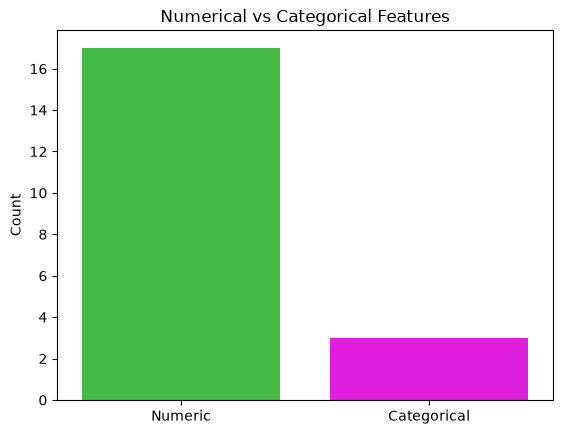

In [ ]:
ax = sns.barplot(x=['Numeric', 'Categorical'], y=[num_ft.shape[0], cat_ft.shape[0]], hue=['Numeric', 'Categorical'], palette=['limegreen', 'magenta'])
# In this case, hue is unnecesary, but it's useful for when I have subcategories (e.g. x='Sex', y='Height', hue='Species')

ax.set_ylabel('Count')
ax.set_title('Numerical vs Categorical Features');

In [ ]:
# New dataset
health = pd.read_csv(data_path/'strokes.csv')
health.dtypes

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [ ]:
# Sanity check for the dataset!
health.isnull()
health.isnull().sum()

health.isnull().mean() * 100 # Percentage of rows with missing values

id                    0.000000
gender                0.000000
age                   0.000000
hypertension          0.000000
heart_disease         0.000000
ever_married          0.000000
work_type             0.000000
Residence_type        0.000000
avg_glucose_level     0.000000
bmi                   3.368664
smoking_status       30.626728
stroke                0.000000
dtype: float64

In [ ]:
# Lets substitute the missing data with "UNK".
# For the bmi, I could as well drop the unknown data, as they are just a 3% of the total data, but I prefer the previous option.

health['bmi'] = health['bmi'].fillna(health['bmi'].median())
health['smoking_status'] = health['smoking_status'].fillna('UNK')

In [ ]:
# Repeat sanity check
health.isnull().sum()
health.dtypes # We also see that we haven't changed the type of the modified categories

id                     int64
gender                   str
age                  float64
hypertension           int64
heart_disease          int64
ever_married             str
work_type                str
Residence_type           str
avg_glucose_level    float64
bmi                  float64
smoking_status           str
stroke                 int64
dtype: object

In [ ]:
health['work_type'].unique()

<StringArray>
['children', 'Private', 'Never_worked', 'Self-employed', 'Govt_job']
Length: 5, dtype: str

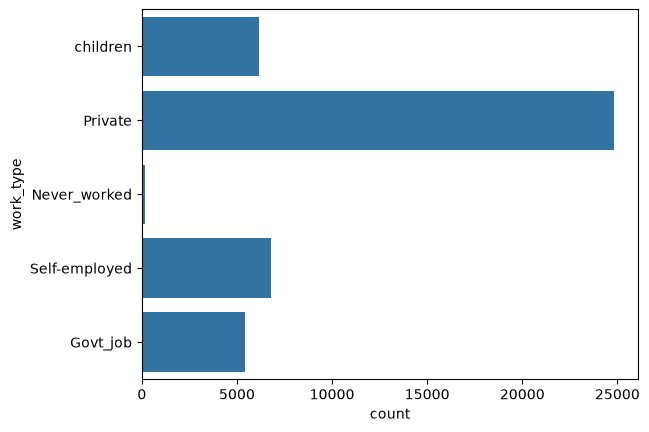

In [ ]:
work = health['work_type']
ax = sns.countplot(work)
plt.show()

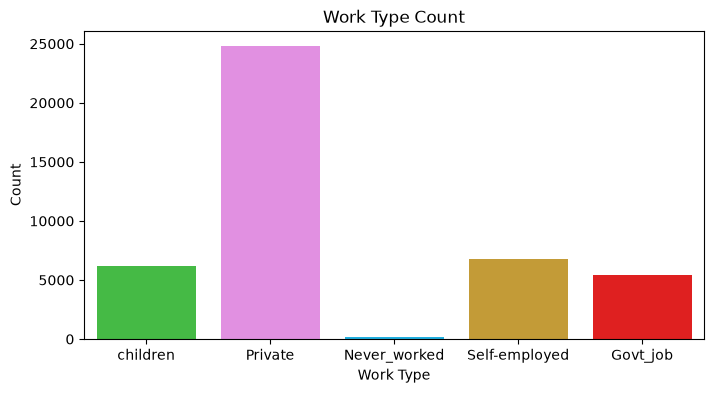

In [ ]:
# (Almost) Equivalently (this is better): 

fig, ax = plt.subplots(figsize=(8, 4))

ax = sns.countplot(data=health, x='work_type', hue='work_type',  palette=('limegreen', 'violet', 'deepskyblue', 'goldenrod', 'red'))
ax.set_xlabel('Work Type')
ax.set_ylabel('Count') 
ax.set_title('Work Type Count')
plt.show()

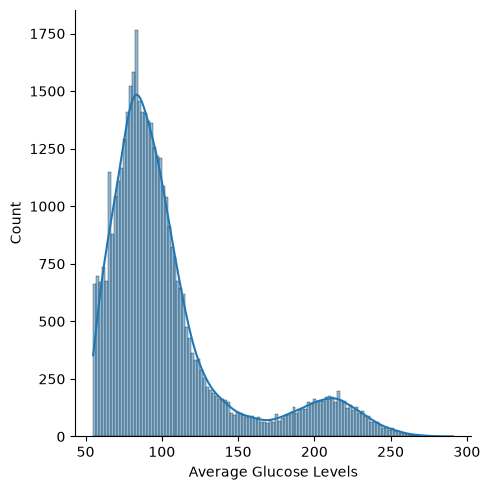

In [ ]:
# And now for a continuous cuantitative feature
ax = sns.displot(data=health, x='avg_glucose_level', kde=True)
ax.set_axis_labels('Average Glucose Levels', 'Count')
plt.show()

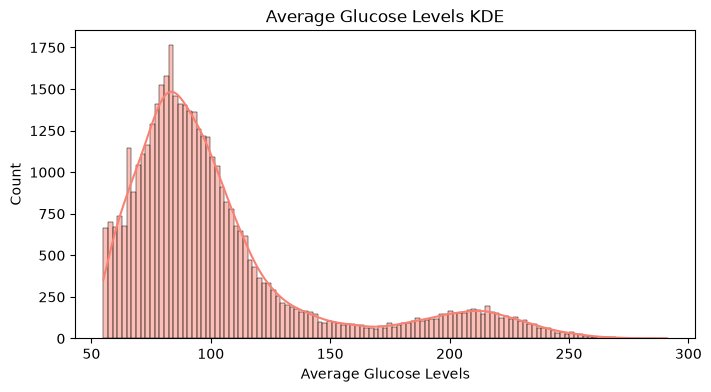

In [ ]:
# Using histplot (better)

fig, ax = plt.subplots(figsize=(8, 4))

sns.histplot(
    data=health,
    x='avg_glucose_level',
    kde=True,
    ax=ax,
    color='salmon'
)

ax.set_xlabel('Average Glucose Levels')
ax.set_ylabel('Count')
ax.set_title('Average Glucose Levels KDE')

plt.show()

In [ ]:
# Changing data type for strokes:

health['stroke'] = (health['stroke']
                    .map({1: 'Yes', 0: 'No'})
                    .astype(str)
)

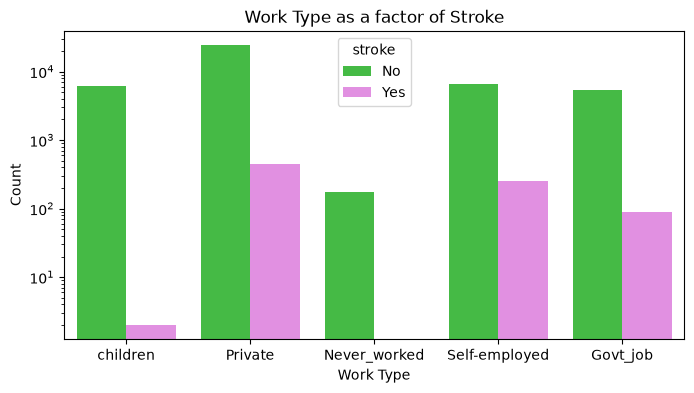

In [ ]:
# Relation between 2 cualitative features:

fig, ax = plt.subplots(figsize=(8, 4))

ax = sns.countplot(data=health, x='work_type', hue=health['stroke'],  palette=('limegreen', 'violet', 'deepskyblue', 'goldenrod', 'red'))

ax.set_xlabel('Work Type')
ax.set_ylabel('Count') 
ax.set_title('Work Type as a factor of Stroke')
ax.set_yscale('log')
plt.show()

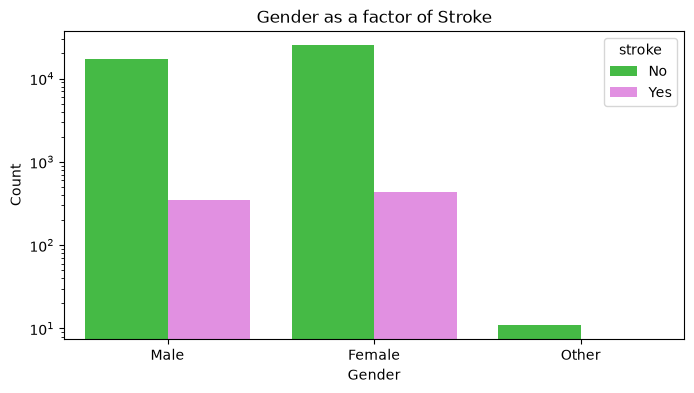

In [ ]:
# What about gender?


fig, ax = plt.subplots(figsize=(8, 4))

ax = sns.countplot(data=health, x='gender', hue=health['stroke'],  palette=('limegreen', 'violet', 'deepskyblue', 'goldenrod', 'red'))

ax.set_xlabel('Gender')
ax.set_ylabel('Count') 
ax.set_title('Gender as a factor of Stroke')
ax.set_yscale('log')
plt.show()

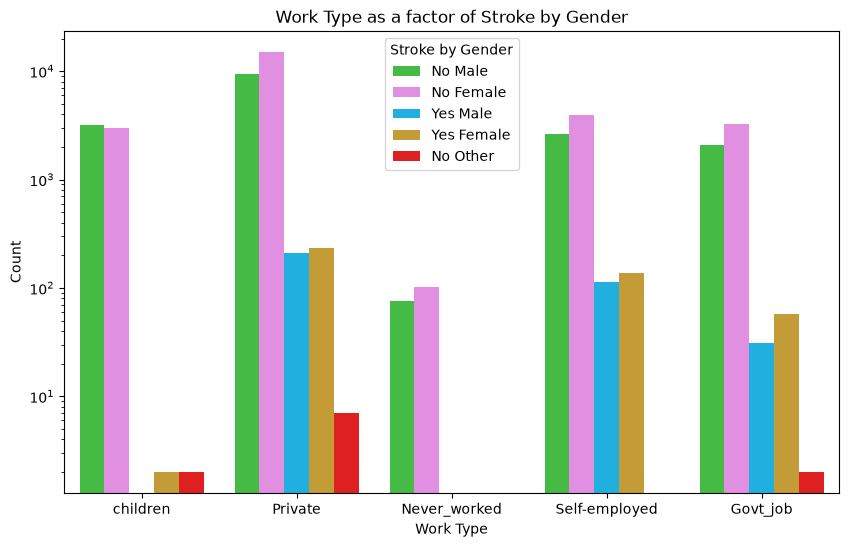

In [ ]:
# And now we mix both of the features!


fig, ax = plt.subplots(figsize=(10, 6))
stroke_gender = health['stroke'].astype(str) + ' ' + health['gender']

ax = sns.countplot(
    data=health,
    x='work_type',
    hue=stroke_gender,
    palette=['limegreen', 'violet', 'deepskyblue', 'goldenrod', 'red']
)

ax.set_xlabel('Work Type')
ax.set_ylabel('Count') 
ax.set_title('Work Type as a factor of Stroke by Gender')
ax.set_yscale('log')
ax.legend(title='Stroke by Gender')
plt.show()

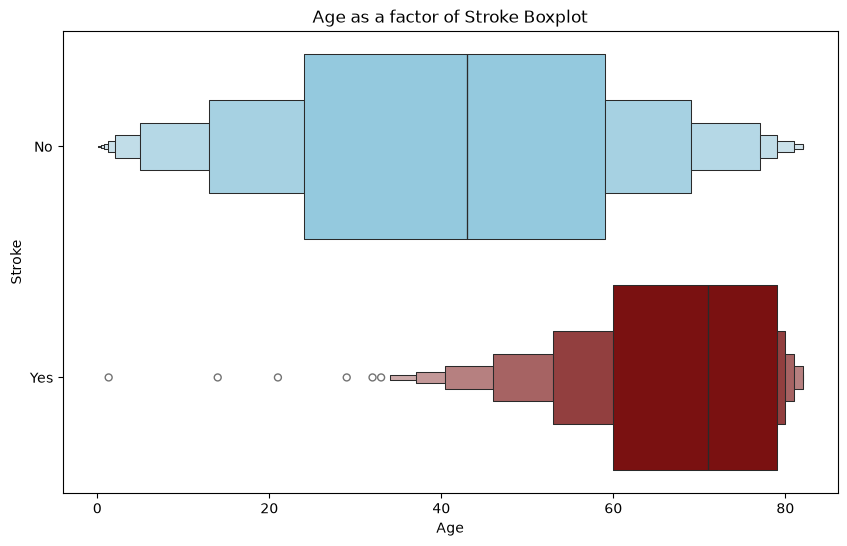

In [ ]:
# What about quantitative+qualitative data? --> We use boxplot


fig, ax = plt.subplots(figsize=(10, 6))

ax = sns.boxenplot(
    data=health,
    x='age',
    y='stroke',
    hue='stroke',
    palette=['skyblue', 'darkred']
)

ax.set_xlabel('Age')
ax.set_ylabel('Stroke') 
ax.set_title('Age as a factor of Stroke Boxplot')
plt.show()

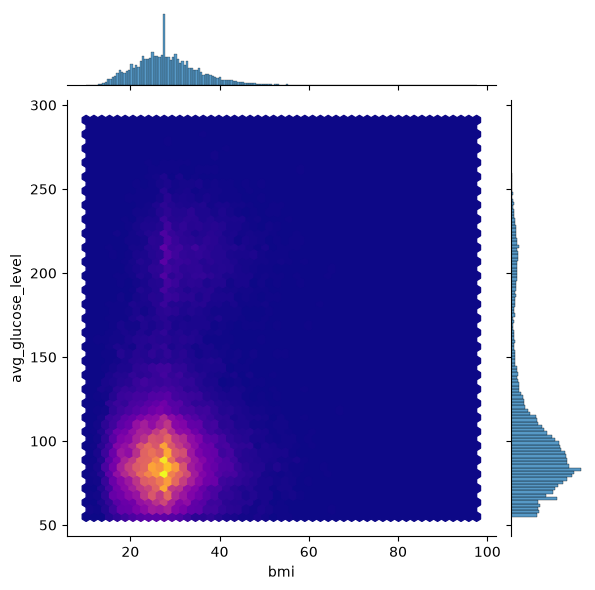

In [ ]:
# And quantitative-quantitative?

quantitative_feat = health.select_dtypes(exclude=str).drop(columns=['id'])

sns.jointplot(data=quantitative_feat, x='bmi', y='avg_glucose_level', kind='hex', cmap='plasma')
plt.show()

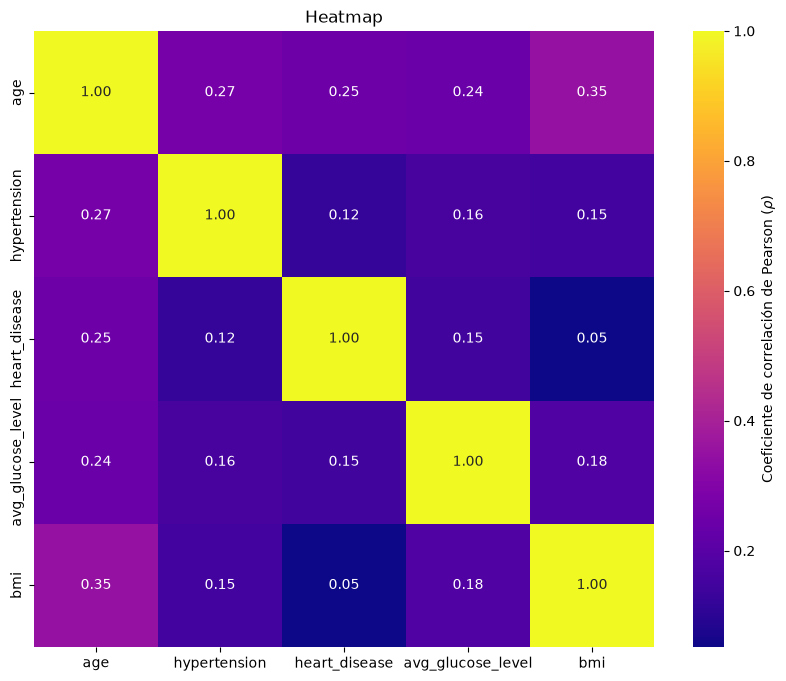

In [ ]:
# Relationship between ALL the features:
fig, ax = plt.subplots(figsize=(10, 8))

corr_matrix = quantitative_feat.corr() 
sns.heatmap(data=corr_matrix, cmap='plasma', ax=ax, annot=True, fmt=".2f", cbar_kws={'label': r'Coeficiente de correlación de Pearson ($\rho$)'})

ax.set_title('Heatmap')
plt.show()